<a href="https://colab.research.google.com/github/FaizunKarim/DTS-Data-Scientist-Supervisor/blob/main/EDA_Mobile_Banking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# ID file dari link Drive
file_id = '1sjv4DkqDTuIXUkUqJAR-r6Zsi-2yT4Ti'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Membaca CSV langsung dari link
data = pd.read_csv(url,  delimiter=";")

# Jumlah data (baris dan kolom)
print("Jumlah data (baris, kolom):", data.shape)

# Informasi tentang tipe data
print("\nInformasi tipe data:")
print(data.info())

# Statistik deskriptif
print("\nStatistik deskriptif:")
print(data.describe())

Jumlah data (baris, kolom): (100, 10)

Informasi tipe data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   nasabah_id                 100 non-null    object
 1   umur                       100 non-null    int64 
 2   jenis_kelamin              100 non-null    object
 3   pendapatan                 100 non-null    int64 
 4   saldo_rata_rata            100 non-null    int64 
 5   jumlah_transaksi           100 non-null    int64 
 6   jenis_produk               100 non-null    object
 7   frekuensi_kunjungi_cabang  100 non-null    int64 
 8   pengguna_mobile_banking    100 non-null    object
 9   skor_kredit                100 non-null    int64 
dtypes: int64(6), object(4)
memory usage: 7.9+ KB
None

Statistik deskriptif:
             umur    pendapatan  saldo_rata_rata  jumlah_transaksi  \
count  100.000000  1.000000e

In [ ]:
# Melakukan pengkodean pada kolom kategorikal dengan mapping yang tepat
data['jenis_kelamin'] = data['jenis_kelamin'].str.strip().map({'Laki-Laki': 1, 'Perempuan': 2})
data['jenis_produk'] = data['jenis_produk'].str.strip().map({'tabungan': 1, 'kartu_kredit': 2, 'deposito': 3})
data['pengguna_mobile_banking'] = data['pengguna_mobile_banking'].str.strip().map({'YA': 1, 'TIDAK': 2})

print("Data setelah pengkodean (5 baris pertama):")
display(data.head())

Data setelah pengkodean (5 baris pertama):


,nasabah_id,umur,jenis_kelamin,pendapatan,saldo_rata_rata,jumlah_transaksi,jenis_produk,frekuensi_kunjungi_cabang,pengguna_mobile_banking,skor_kredit
0,N001,22,2,5800000,1508000,19,1,1,2,900
1,N002,64,2,5700000,1254000,9,2,2,2,900
2,N003,27,2,2950000,590000,12,1,1,1,500
3,N004,34,2,3100000,186000,16,3,5,2,700
4,N005,45,1,6700000,1474000,15,2,3,1,800


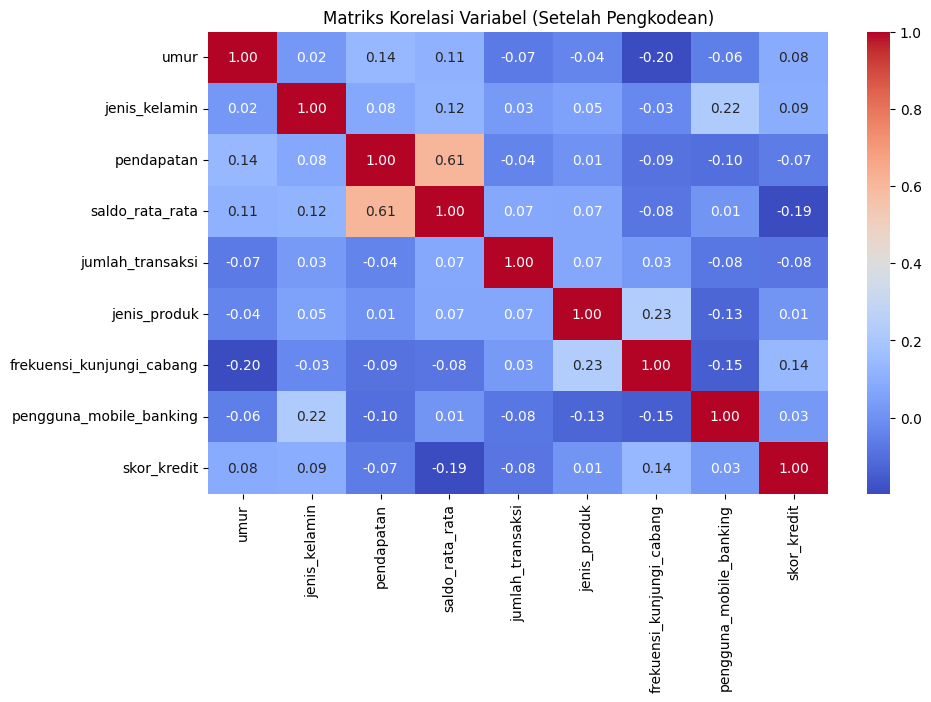

In [ ]:
# 1. Korelasi antar variabel numerik
plt.figure(figsize=(10, 6))
# Menggunakan numeric_only=True untuk memastikan hanya kolom angka yang dihitung
corr_matrix = data.drop(columns=['nasabah_id']).corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Variabel (Setelah Pengkodean)')
plt.show()

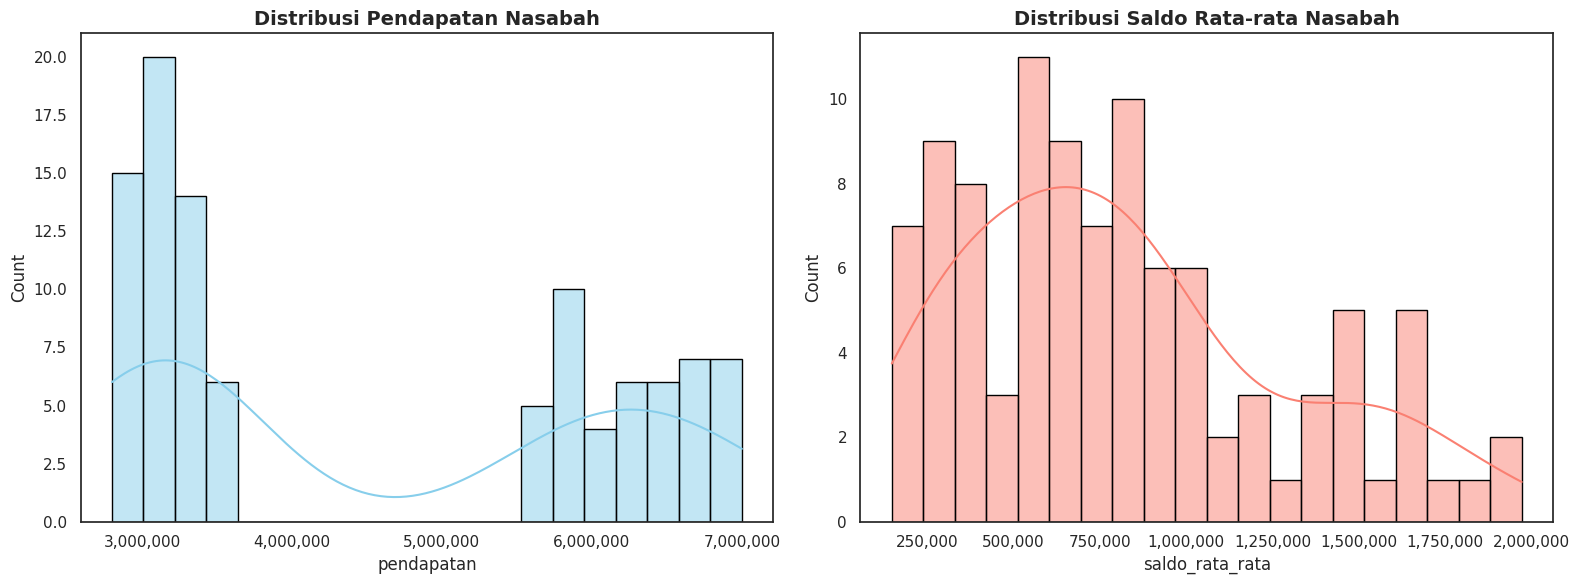

In [ ]:
# 2. Distribusi Pendapatan dan Saldo (Versi Bersih Tanpa Grid/Garis Statistik)
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Distribusi Pendapatan
sns.histplot(data['pendapatan'], kde=True, ax=axes[0], color='skyblue', bins=20, edgecolor='black')
axes[0].set_title('Distribusi Pendapatan Nasabah', fontsize=14, fontweight='bold')
axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Plot Distribusi Saldo Rata-rata
sns.histplot(data['saldo_rata_rata'], kde=True, ax=axes[1], color='salmon', bins=20, edgecolor='black')
axes[1].set_title('Distribusi Saldo Rata-rata Nasabah', fontsize=14, fontweight='bold')
axes[1].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

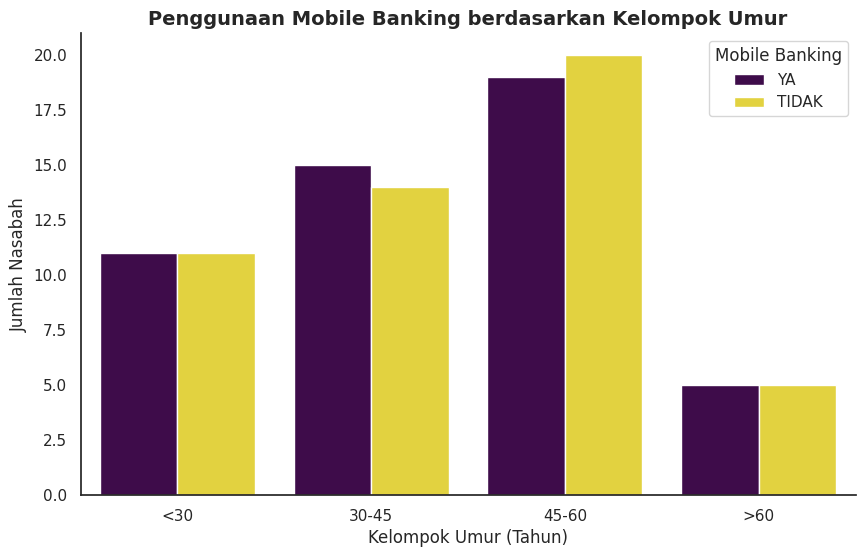

In [ ]:
# 3. Analisis Penggunaan Mobile Banking berdasarkan Kelompok Umur
plt.figure(figsize=(10, 6))
sns.set_theme(style="white")

# Memastikan kolom kelompok_umur tersedia
if 'kelompok_umur' not in data.columns:
    data['kelompok_umur'] = pd.cut(data['umur'], bins=[0, 30, 45, 60, 100], labels=['<30', '30-45', '45-60', '>60'])

# Membuat countplot dengan palet warna yang kontras
ax = sns.countplot(data=data, x='kelompok_umur', hue='pengguna_mobile_banking', palette='viridis')

plt.title('Penggunaan Mobile Banking berdasarkan Kelompok Umur', fontsize=14, fontweight='bold')
plt.xlabel('Kelompok Umur (Tahun)', fontsize=12)
plt.ylabel('Jumlah Nasabah', fontsize=12)

# Mengganti label legend dari angka 1/2 menjadi teks yang jelas
plt.legend(title='Mobile Banking', labels=['YA', 'TIDAK'])

# Menghilangkan garis tepi untuk tampilan lebih bersih
sns.despine()
plt.show()

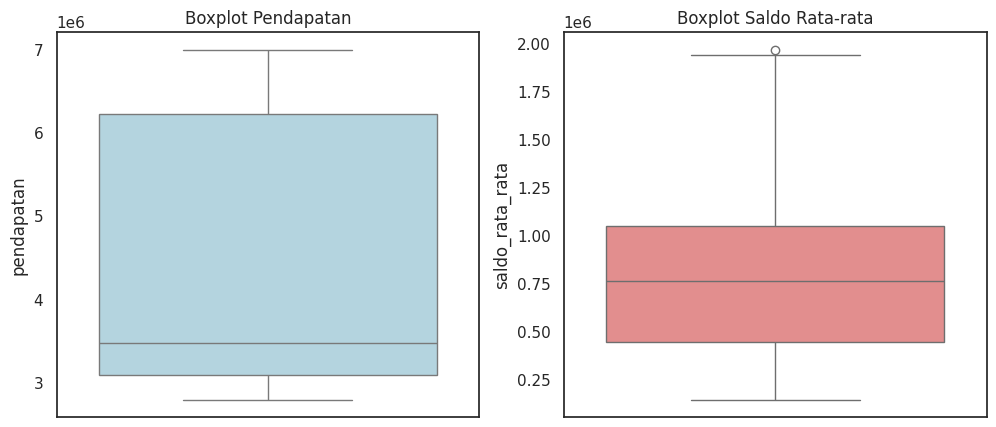

In [ ]:
# 4. Deteksi Outlier pada Pendapatan dan Saldo
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=data['pendapatan'], color='lightblue')
plt.title('Boxplot Pendapatan')

plt.subplot(1, 2, 2)
sns.boxplot(y=data['saldo_rata_rata'], color='lightcoral')
plt.title('Boxplot Saldo Rata-rata')
plt.show()

<Figure size 1000x600 with 0 Axes>

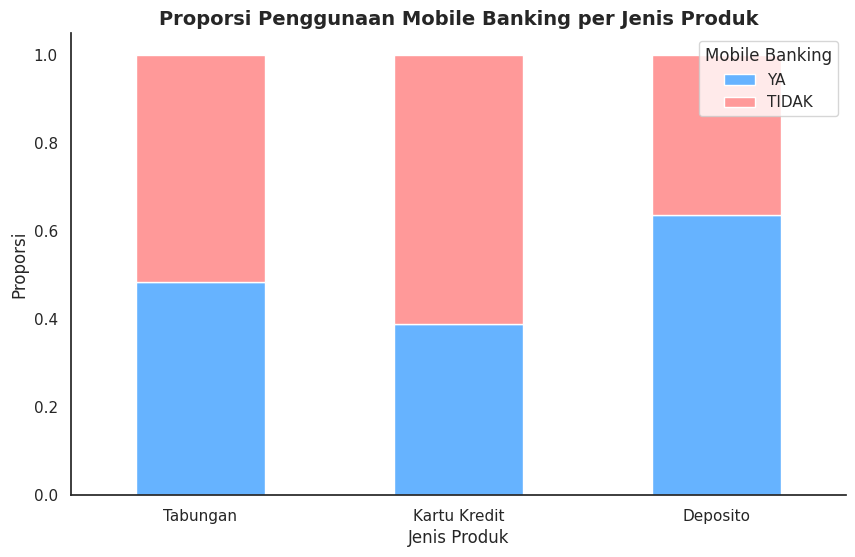

In [ ]:
# 5. Hubungan antara Jenis Produk dan Penggunaan Mobile Banking
ct = pd.crosstab(data['jenis_produk'], data['pengguna_mobile_banking'], normalize='index')

plt.figure(figsize=(10, 6))
sns.set_theme(style="white")
ax = ct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66b3ff','#ff9999'])

plt.title('Proporsi Penggunaan Mobile Banking per Jenis Produk', fontsize=14, fontweight='bold')
plt.ylabel('Proporsi')
plt.xlabel('Jenis Produk')
plt.xticks(ticks=[0, 1, 2], labels=['Tabungan', 'Kartu Kredit', 'Deposito'], rotation=0)

# Mengganti legend agar jelas
plt.legend(title='Mobile Banking', labels=['YA', 'TIDAK'], loc='upper right')

sns.despine()
plt.show()

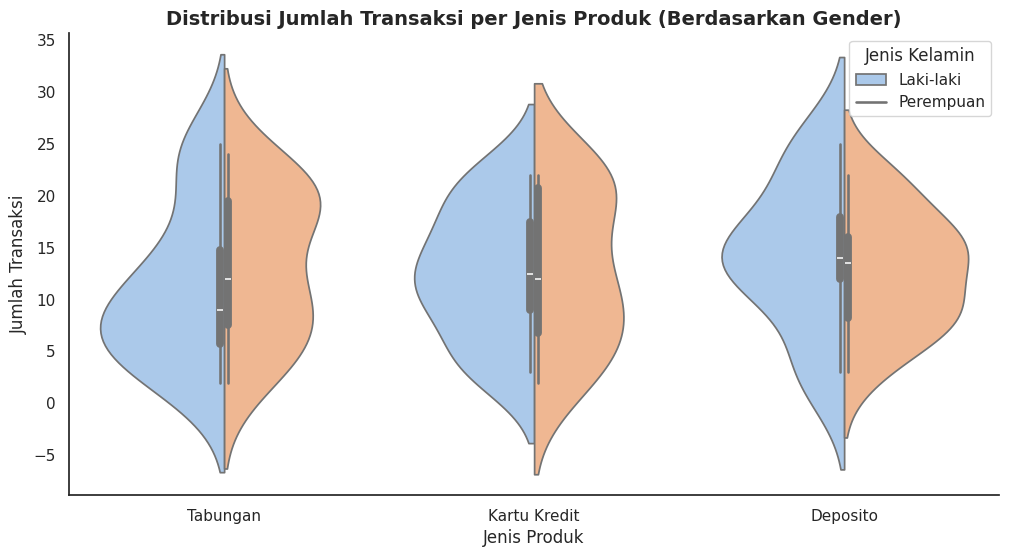

In [ ]:
# 6. Analisis Lanjutan: Violin Plot untuk Jumlah Transaksi per Produk
plt.figure(figsize=(12, 6))
sns.set_theme(style="white")

# Membuat violin plot dengan label gender yang jelas
ax = sns.violinplot(data=data, x='jenis_produk', y='jumlah_transaksi', hue='jenis_kelamin',
                    split=True, palette='pastel')

plt.title('Distribusi Jumlah Transaksi per Jenis Produk (Berdasarkan Gender)', fontsize=14, fontweight='bold')
plt.xticks(ticks=[0, 1, 2], labels=['Tabungan', 'Kartu Kredit', 'Deposito'])
plt.xlabel('Jenis Produk')
plt.ylabel('Jumlah Transaksi')

# Memperbaiki legend gender agar tidak menggunakan angka 1/2
plt.legend(title='Jenis Kelamin', labels=['Laki-laki', 'Perempuan'])

sns.despine()
plt.show()

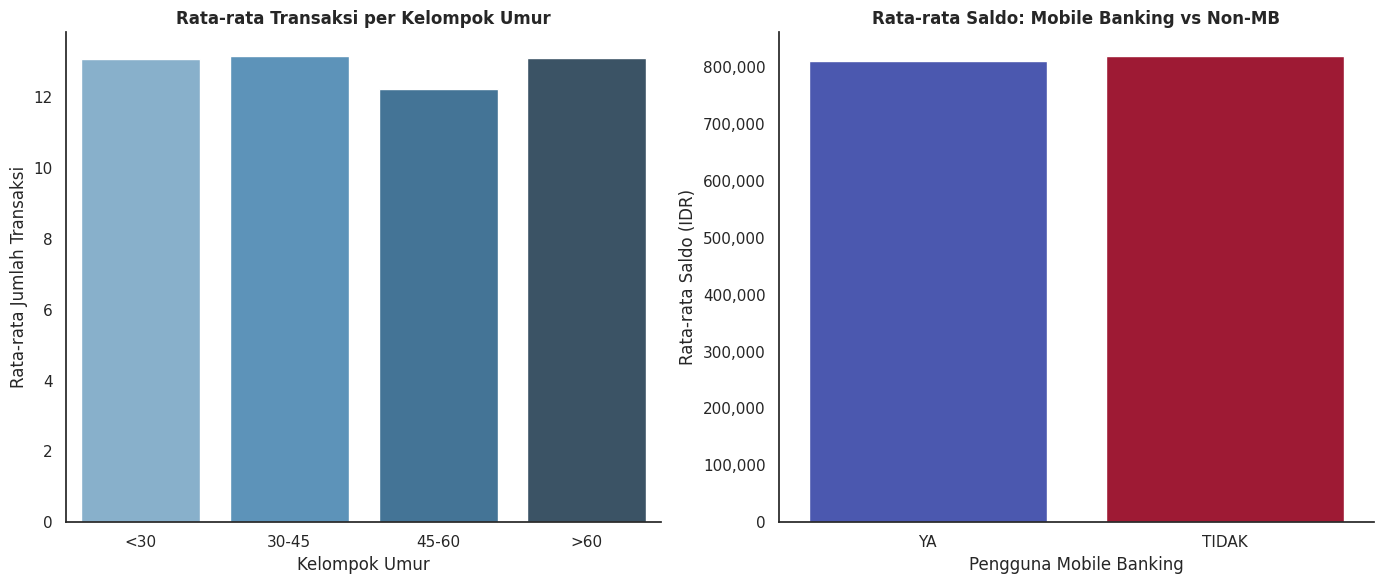

In [ ]:
# 7. Visualisasi Rata-rata Jumlah Transaksi per Kelompok Umur
plt.figure(figsize=(14, 6))
sns.set_theme(style="white")

plt.subplot(1, 2, 1)
summary_transaksi = data.groupby('kelompok_umur', observed=False)['jumlah_transaksi'].mean().reset_index()
# Memperbaiki FutureWarning dengan menambahkan hue='kelompok_umur'
sns.barplot(data=summary_transaksi, x='kelompok_umur', y='jumlah_transaksi', hue='kelompok_umur', palette='Blues_d', legend=False)
plt.title('Rata-rata Transaksi per Kelompok Umur', fontsize=12, fontweight='bold')
plt.xlabel('Kelompok Umur')
plt.ylabel('Rata-rata Jumlah Transaksi')
sns.despine()

# 8. Visualisasi Saldo Rata-rata berdasarkan Penggunaan Mobile Banking
plt.subplot(1, 2, 2)
# Memperbaiki FutureWarning dengan menambahkan hue='pengguna_mobile_banking'
sns.barplot(data=data, x='pengguna_mobile_banking', y='saldo_rata_rata', hue='pengguna_mobile_banking', palette='coolwarm', errorbar=None, legend=False)
plt.title('Rata-rata Saldo: Mobile Banking vs Non-MB', fontsize=12, fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['YA', 'TIDAK'])
plt.xlabel('Pengguna Mobile Banking')
plt.ylabel('Rata-rata Saldo (IDR)')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
sns.despine()

plt.tight_layout()
plt.show()